# Task 1 - Time Series Analysis

Description: Analyze and model time-series data to forecast future values (e.g., stock prices, sales).

Objectives:

.Plot and decompose the time series into trend, seasonality, and residual components.

.Implement moving average and exponential smoothing techniques.

.Build an ARIMA or SARIMA model for forecasting.

.Evaluate the model using metrics such as RMSE and visualize the forecast.

.Tools: Python, pandas, statsmodels, matplotlib.

Here I am going to be Using Data set from UCI Online Retail Dataset- https://archive.ics.uci.edu/dataset/352/online+retail

In [4]:
import os

print(os.getcwd())


c:\Users\JOSMAN\Documents\DATA SCIENCE AND ANALYTICS\CODVEDA PROJECTS\PROJECT 3\Time Series Analysis


In [5]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [6]:
#Loading the Dataset

import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
print(df.shape)
print(df.columns)


(541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [9]:
#Checking the transaction Values for the dataset

print(df["Quantity"].describe())
print()
print(df["UnitPrice"].describe())


count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64


In [10]:
print(df["InvoiceNo"].astype(str).str.startswith("C").value_counts())


InvoiceNo
False    532621
True       9288
Name: count, dtype: int64


In [11]:
#Creating A Sales DataFrame

sales_df = df[~df["InvoiceNo"].astype(str).str.startswith("C")].copy()

print(sales_df.shape)

(532621, 8)


In [12]:
sales_df["Revenue"] = sales_df["Quantity"] * sales_df["UnitPrice"]

sales_df[["InvoiceDate", "Quantity", "UnitPrice", "Revenue"]].head()

,InvoiceDate,Quantity,UnitPrice,Revenue
0,2010-12-01 08:26:00,6,2.55,15.30
1,2010-12-01 08:26:00,6,3.39,20.34
2,2010-12-01 08:26:00,8,2.75,22.00
3,2010-12-01 08:26:00,6,3.39,20.34
4,2010-12-01 08:26:00,6,3.39,20.34


The dataset contains individual transactions at different times. For time-series analysis, we need to aggregate those transactions into a regular time interval. We'll use daily revenue, because the dataset has dates spanning about a year and daily data gives us enough observations to examine trend and weekly seasonality.

In [13]:
#Creating Daily Revenue
daily_sales = sales_df.groupby(
    sales_df["InvoiceDate"].dt.date
)["Revenue"].sum()

daily_sales.head()

InvoiceDate
2010-12-01    58960.79
2010-12-02    47748.38
2010-12-03    46943.71
2010-12-05    31774.95
2010-12-06    54830.46
Name: Revenue, dtype: float64

In [14]:
print("Number of days:", len(daily_sales))
print("Start date:", daily_sales.index.min())
print("End date:", daily_sales.index.max())

Number of days: 305
Start date: 2010-12-01
End date: 2011-12-09


In [15]:
#Identifying Missing Dates

all_dates = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq="D"
)

missing_dates = all_dates.difference(pd.to_datetime(daily_sales.index))

print("Expected calendar days:", len(all_dates))
print("Missing dates:", len(missing_dates))
print(missing_dates[:20])

Expected calendar days: 374
Missing dates: 69
DatetimeIndex(['2010-12-04', '2010-12-11', '2010-12-18', '2010-12-24',
               '2010-12-25', '2010-12-26', '2010-12-27', '2010-12-28',
               '2010-12-29', '2010-12-30', '2010-12-31', '2011-01-01',
               '2011-01-02', '2011-01-03', '2011-01-08', '2011-01-15',
               '2011-01-22', '2011-01-29', '2011-02-05', '2011-02-12'],
              dtype='datetime64[s]', freq=None)


In [16]:
#Creating A Complete Daily Time Series

daily_sales.index = pd.to_datetime(daily_sales.index)

daily_sales = daily_sales.asfreq("D", fill_value=0)

print(daily_sales.head(10))
print()
print("Number of days:", len(daily_sales))

InvoiceDate
2010-12-01    58960.79
2010-12-02    47748.38
2010-12-03    46943.71
2010-12-04        0.00
2010-12-05    31774.95
2010-12-06    54830.46
2010-12-07    99618.20
2010-12-08    45389.98
2010-12-09    53586.18
2010-12-10    59182.92
Freq: D, Name: Revenue, dtype: float64

Number of days: 374


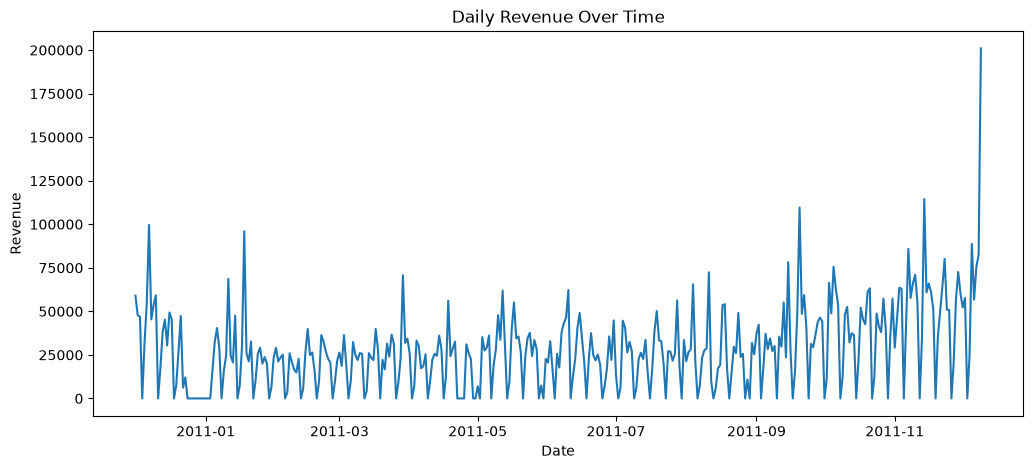

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(daily_sales)
plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [18]:
daily_sales.groupby(daily_sales.index.dayofweek).mean()

InvoiceDate
0    33576.887566
1    41106.275679
2    34280.515000
3    40799.282222
4    33670.668722
5        0.000000
6    15355.237943
Name: Revenue, dtype: float64

In [19]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    daily_sales,
    model="additive",
    period=7
)

decomposition.plot(figsize=(12, 8))
plt.show()

TypeError: DecomposeResult.plot() got an unexpected keyword argument 'figsize'

In [ ]:
print("daily_sales" in globals())


False


In [28]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

sales_df = df[~df["InvoiceNo"].astype(str).str.startswith("C")].copy()

sales_df["Revenue"] = sales_df["Quantity"] * sales_df["UnitPrice"]

In [23]:
daily_sales = sales_df.groupby(
    sales_df["InvoiceDate"].dt.date
)["Revenue"].sum()

daily_sales.index = pd.to_datetime(daily_sales.index)

daily_sales = daily_sales.asfreq("D", fill_value=0)

print(daily_sales.head())
print("Number of days:", len(daily_sales))

InvoiceDate
2010-12-01    58960.79
2010-12-02    47748.38
2010-12-03    46943.71
2010-12-04        0.00
2010-12-05    31774.95
Freq: D, Name: Revenue, dtype: float64
Number of days: 374


In [29]:
#Decomposing the Time Series

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    daily_sales,
    model="additive",
    period=7
)

decomposition.plot(figsize=(12, 8))
plt.show()

TypeError: DecomposeResult.plot() got an unexpected keyword argument 'figsize'

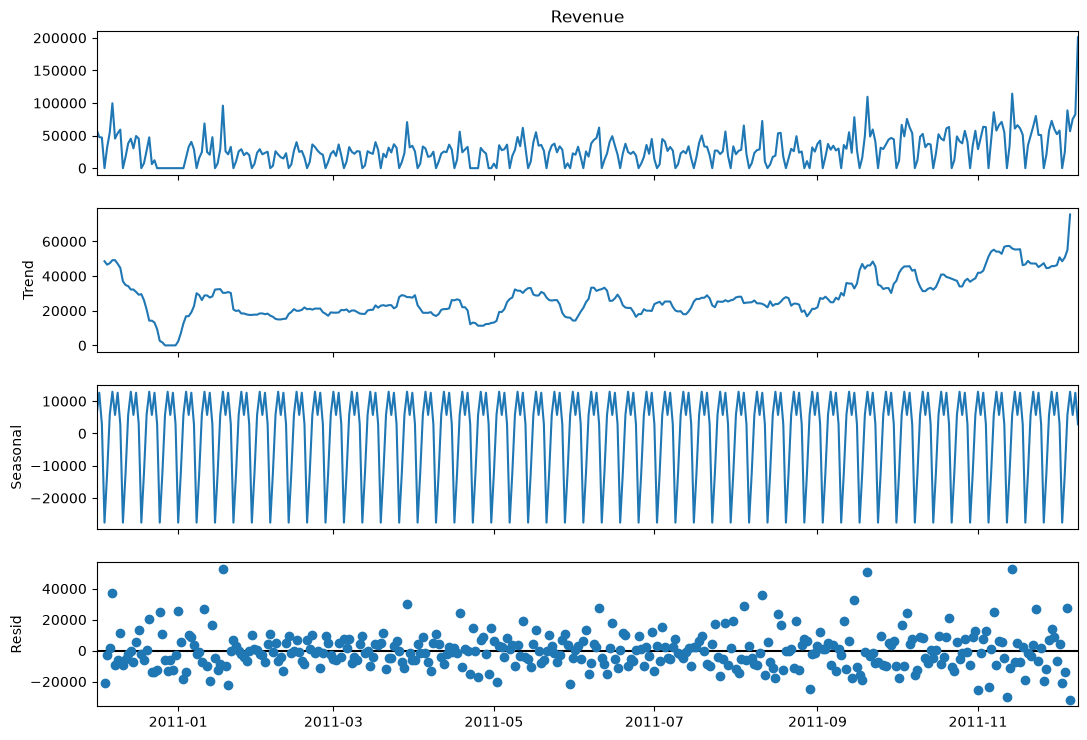

In [25]:
fig = decomposition.plot()
fig.set_size_inches(12, 8)

plt.show()

# Moving Average

Implement moving average and exponential smoothing techniques.

We'll start with a 7-day moving average, which makes sense because we identified weekly seasonality.

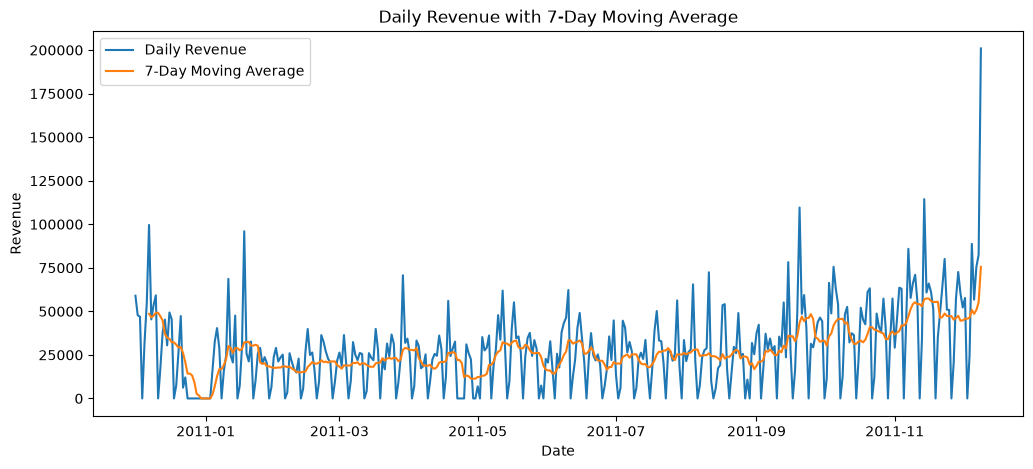

In [26]:
moving_average = daily_sales.rolling(window=7).mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_sales, label="Daily Revenue")
plt.plot(moving_average, label="7-Day Moving Average")
plt.title("Daily Revenue with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

The 7-day moving average cuts across the daily revenue line because it smooths the day-to-day fluctuations.

It Implies:

Daily Revenue line: reacts to every day's rise and fall.

7-Day Moving Average: takes the average of a rolling 7-day window, so sudden spikes and drops are softened.

Where the moving-average line rises, the underlying revenue level is generally increasing.

Where it falls, the underlying level is generally decreasing.

#Exponential Smoothing


In [30]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

model = SimpleExpSmoothing(daily_sales)
fit = model.fit()

exponential_smoothing = fit.fittedvalues

plt.figure(figsize=(12, 5))
plt.plot(daily_sales, label="Daily Revenue")
plt.plot(exponential_smoothing, label="Exponential Smoothing")
plt.title("Daily Revenue with Exponential Smoothing")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

TypeError: initialization_method must be a string

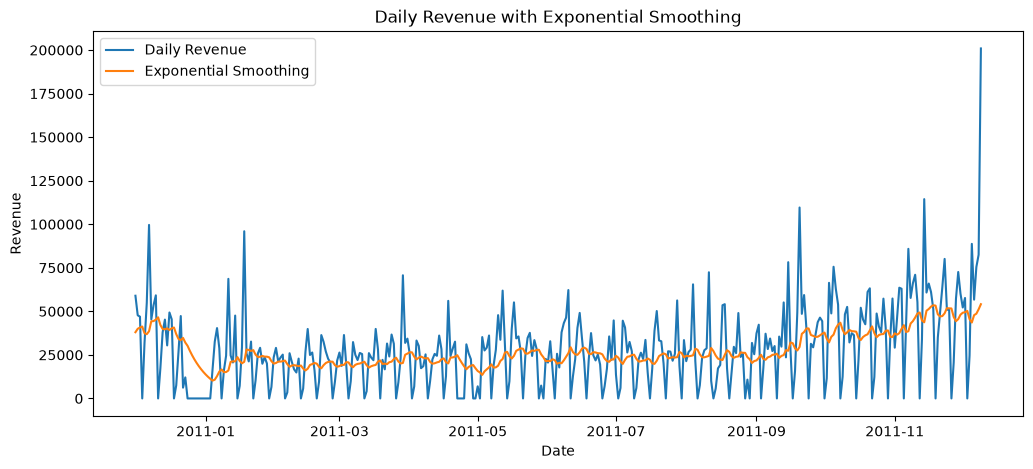

In [31]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

model = SimpleExpSmoothing(
    daily_sales,
    initialization_method="estimated"
)

fit = model.fit()

exponential_smoothing = fit.fittedvalues

plt.figure(figsize=(12, 5))
plt.plot(daily_sales, label="Daily Revenue")
plt.plot(exponential_smoothing, label="Exponential Smoothing")
plt.title("Daily Revenue with Exponential Smoothing")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

ARIMA forecasting

In [32]:
#Splitting the data into training and testing sets

train = daily_sales[:-30]
test = daily_sales[-30:]

print("Training data:", len(train))
print("Testing data:", len(test))

Training data: 344
Testing data: 30


In [33]:
#Building the ARIMA Model

from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order=(1, 1, 1))
arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  344
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3857.191
Date:                Thu, 24 Sep 2026   AIC                           7720.383
Time:                        16:31:51   BIC                           7731.896
Sample:                    12-01-2010   HQIC                          7724.969
                         - 11-09-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2962      0.079      3.755      0.000       0.142       0.451
ma.L1         -0.9673      0.022    -44.291      0.000      -1.010      -0.925
sigma2      4.137e+08   3.56e-11   1.16e+19      0.0

In [34]:
#Generate the Forecast

forecast = arima_fit.forecast(steps=30)

print(forecast)

2011-11-10    47597.924975
2011-11-11    42109.757227
2011-11-12    40484.254678
2011-11-13    40002.808290
2011-11-14    39860.212005
2011-11-15    39817.977395
2011-11-16    39805.468217
2011-11-17    39801.763210
2011-11-18    39800.665850
2011-11-19    39800.340830
2011-11-20    39800.244565
2011-11-21    39800.216053
2011-11-22    39800.207608
2011-11-23    39800.205107
2011-11-24    39800.204366
2011-11-25    39800.204146
2011-11-26    39800.204081
2011-11-27    39800.204062
2011-11-28    39800.204056
2011-11-29    39800.204055
2011-11-30    39800.204054
2011-12-01    39800.204054
2011-12-02    39800.204054
2011-12-03    39800.204054
2011-12-04    39800.204054
2011-12-05    39800.204054
2011-12-06    39800.204054
2011-12-07    39800.204054
2011-12-08    39800.204054
2011-12-09    39800.204054
Freq: D, Name: predicted_mean, dtype: float64


In [35]:
#Calculating RMSE

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))

print("RMSE:", rmse)

RMSE: 41471.107255589355


# Visual Display of the Forecast

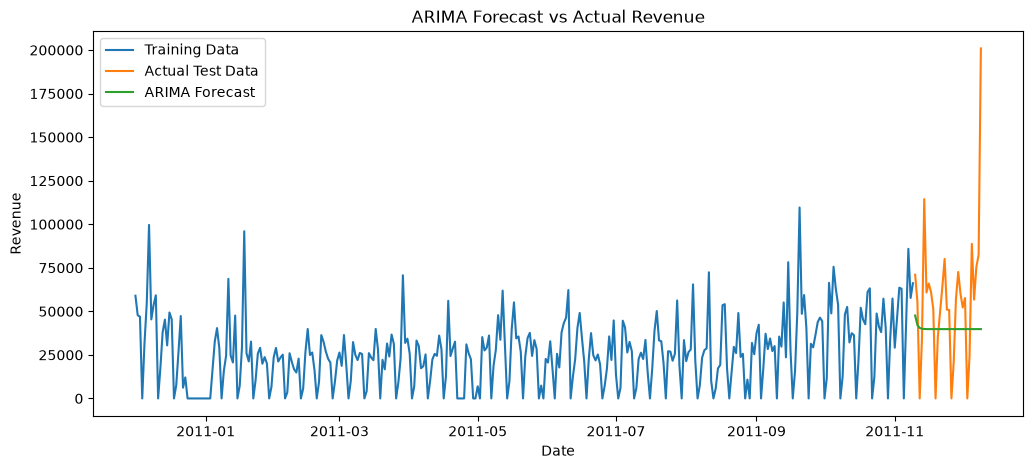

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Test Data")
plt.plot(test.index, forecast, label="ARIMA Forecast")

plt.title("ARIMA Forecast vs Actual Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

# Project 3 — Task 1: Time Series Analysis

## Objective

The objective of this task was to analyze historical time-series data and build a model for forecasting future values. The UCI Online Retail dataset was used, with daily revenue as the target time series.

## Data Preparation

The dataset contained **541,909 transaction records** and 8 columns. Cancelled invoices were removed, and revenue was calculated as:

**Revenue = Quantity × UnitPrice**

Transactions were then aggregated by date to obtain daily revenue. Missing calendar dates were included as zero-revenue days, producing a continuous time series of **374 days**, from **December 1, 2010 to December 9, 2011**.

## Time-Series Analysis

The daily revenue series was plotted to examine its overall behavior. A weekly pattern was investigated, and a **7-day seasonal period** was selected for decomposition.

The time series was decomposed into:

* **Observed:** Original daily revenue
* **Trend:** Long-term movement in revenue
* **Seasonal:** Repeating weekly pattern
* **Residual:** Irregular variation not explained by trend or seasonality

## Moving Average

A **7-day moving average** was calculated to smooth short-term fluctuations in daily revenue. The moving average produced a smoother representation of the underlying revenue movement.

## Exponential Smoothing

**Simple Exponential Smoothing** was implemented. Unlike the moving average, exponential smoothing gives greater importance to more recent observations, producing a smoothed representation of the revenue series.

## ARIMA Forecasting

The dataset was divided chronologically into:

* **Training data:** 344 days
* **Testing data:** 30 days

An **ARIMA(1,1,1)** model was fitted using the training data and used to forecast the 30-day test period.

## Model Evaluation

The forecasts were evaluated using **Root Mean Squared Error (RMSE)**.

**RMSE = 41,471.11**

The forecast was also visualized alongside the actual test-period revenue to compare the model's predictions with observed values.

## Conclusion

The analysis demonstrated the major stages of time-series forecasting: preparing a continuous time series, identifying seasonal patterns, decomposing the series, smoothing the data using moving averages and exponential smoothing, fitting an ARIMA model, generating forecasts, and evaluating the forecasts using RMSE.
